# Large-Scale Drug Portfolio Selection: Why QAOA Is Interesting

This notebook is a concept demo for a harder pharma portfolio selection problem:

> Choose 50 molecules out of 10,000 while balancing solubility, toxicity, synthesis cost, similarity, scaffold diversity, molecular weight, acid/base profile, and patent freedom.

Important honesty note:

- We do **not** run QAOA on all 10,000 molecules.
- Direct QAOA would require thousands of binary variables and far more qubits than are practical today.
- Instead, we show the realistic hybrid pattern: score/filter a large library classically, then run QAOA on a small shortlisted problem.

So the goal is not to prove quantum advantage. The goal is to show where quantum optimization would fit in a pharma ML pipeline.


## 1. Why the Full Problem Is Hard

Classical optimization is not bad. Classical methods are excellent and should be the first baseline.

The challenge is combinatorial scale. If we choose 50 molecules from 10,000 candidates, the number of possible portfolios is:

$$\binom{10000}{50}$$

That is too large for brute force. Diversity constraints make it harder because molecule similarity creates pairwise terms between candidates. With 10,000 molecules, there can be roughly 50 million pairwise relationships.

QAOA is interesting because this kind of binary selection can be written as a QUBO/Ising optimization problem. But current hardware still requires us to reduce the problem size first.

In [1]:
from math import comb, log10
from pathlib import Path
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 7
SCREENING_LIBRARY_SIZE = 10_000
FULL_PORTFOLIO_SELECT_COUNT = 50
REDUCED_QAOA_SELECT_COUNT = 3
QAOA_REPS = 1
QAOA_MAXITER = 40
SAMPLER_SHOTS = 4096

rng = np.random.default_rng(RANDOM_SEED)


In [2]:
n_candidates = SCREENING_LIBRARY_SIZE
n_select = FULL_PORTFOLIO_SELECT_COUNT
log10_portfolios = log10(comb(n_candidates, n_select))
pairwise_terms = n_candidates * (n_candidates - 1) // 2

print(f"log10(number of ways to choose {n_select} from {n_candidates}): {log10_portfolios:.1f}")
print(f"Approximate pairwise similarity terms: {pairwise_terms:,}")


log10(number of ways to choose 50 from 10000): 135.5
Approximate pairwise similarity terms: 49,995,000


## 2. Build a 10,000-Molecule-Like Screening Library

The ESOL dataset has 1,128 real molecules. For a large-scale concept demo, we bootstrap from ESOL and add small descriptor noise to create a 10,000-row screening library.

This keeps the notebook lightweight and reproducible without requiring a huge external dataset.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
local_paths = [Path("data/delaney-processed.csv"), Path("../data/delaney-processed.csv")]
data_path = next((path for path in local_paths if path.exists()), None)
esol = pd.read_csv(data_path if data_path else DATA_URL)

descriptor_cols = [
    "ESOL predicted log solubility in mols per litre",
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
target_col = "measured log solubility in mols per litre"

library = esol.sample(n_candidates, replace=True, random_state=RANDOM_SEED).reset_index(drop=True)
library["library_id"] = [f"LIB_{i:05d}" for i in range(len(library))]

# Add light numeric variation so bootstrapped rows are not exact duplicates.
library["Molecular Weight"] = (library["Molecular Weight"] + rng.normal(0, 8, len(library))).clip(50, 800)
library["Polar Surface Area"] = (library["Polar Surface Area"] + rng.normal(0, 5, len(library))).clip(0, 250)
library["Number of Rotatable Bonds"] = (library["Number of Rotatable Bonds"] + rng.integers(-1, 2, len(library))).clip(0, 20)
library["Number of H-Bond Donors"] = (library["Number of H-Bond Donors"] + rng.integers(-1, 2, len(library))).clip(0, 10)
library["Number of Rings"] = (library["Number of Rings"] + rng.integers(-1, 2, len(library))).clip(0, 8)

print("Screening library rows:", len(library))
library[["library_id", "Compound ID", "smiles", target_col, "Molecular Weight", "Polar Surface Area"]].head()


Screening library rows: 10000


,library_id,Compound ID,smiles,measured log solubility in mols per litre,Molecular Weight,Polar Surface Area
0,LIB_00000,3-Heptanoyloxymethylphenytoin,O=C1N(COC(=O)CCCCCC)C(=O)C(N1)(c2ccccc2)c3ccccc3,-6.301,394.480841,72.059825
1,LIB_00001,Salicin,OCC2OC(Oc1ccccc1CO)C(O)C(O)C2O,-0.850,288.669964,119.579702
2,LIB_00002,Methazole,Cn2c(=O)on(c1ccc(Cl)c(Cl)c1)c2=O,-2.820,258.870897,53.550726
3,LIB_00003,"2,2-Dimethylpentane",CCCC(C)(C)C,-4.360,93.080265,11.202641
4,LIB_00004,Methyl acetate,COC(=O)C,0.460,70.441634,31.000930


## 3. Train a Classical ML Scoring Model

ML predicts molecular properties. QAOA does not. Here we train a simple Random Forest on ESOL and use it to score the large screening library.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = esol[descriptor_cols]
y = esol[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED
)

model = RandomForestRegressor(n_estimators=250, min_samples_leaf=2, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)

rmse = mean_squared_error(y_test, test_predictions) ** 0.5
print("Prediction metrics on ESOL test split")
print("MAE:", round(mean_absolute_error(y_test, test_predictions), 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2_score(y_test, test_predictions), 3))

library["predicted_solubility"] = model.predict(library[descriptor_cols])

Prediction metrics on ESOL test split
MAE: 0.484
RMSE: 0.666
R2: 0.902


## 4. Add Portfolio Constraints and Proxy Scores

A real pharma workflow would use measured or predicted values for toxicity, synthesis cost, acid/base profile, patent freedom, and scaffold class.

For this concept notebook, we create transparent proxy features from molecular descriptors:

- toxicity risk increases with high molecular weight, high lipophilicity proxy, and low solubility
- synthesis cost increases with molecular weight, rings, and rotatable bonds
- acid/base profile uses H-bond donors as acid-site proxy and descriptor-derived acceptor proxy
- patent freedom is a reproducible synthetic score
- scaffold group is approximated with descriptor clusters

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def minmax_array(values):
    values = np.asarray(values).reshape(-1, 1)
    return MinMaxScaler().fit_transform(values).ravel()


library["mw_norm"] = minmax_array(library["Molecular Weight"])
library["psa_norm"] = minmax_array(library["Polar Surface Area"])
library["rot_norm"] = minmax_array(library["Number of Rotatable Bonds"])
library["rings_norm"] = minmax_array(library["Number of Rings"])
library["solubility_norm"] = minmax_array(library["predicted_solubility"])

library["toxicity_risk"] = (
    0.45 * library["mw_norm"]
    + 0.25 * library["rings_norm"]
    + 0.30 * (1 - library["solubility_norm"])
).clip(0, 1)
library["synthesis_cost"] = (
    500
    + 2200 * library["mw_norm"]
    + 900 * library["rings_norm"]
    + 650 * library["rot_norm"]
)
library["acid_sites"] = library["Number of H-Bond Donors"].round().astype(int).clip(0, 8)
library["base_sites"] = (
    (library["Polar Surface Area"] / 45) - 0.4 * library["acid_sites"]
).round().astype(int).clip(0, 8)
library["patent_freedom"] = rng.beta(5, 2, len(library))

cluster_features = StandardScaler().fit_transform(
    library[["Molecular Weight", "Polar Surface Area", "Number of Rings", "Number of Rotatable Bonds"]]
)
library["scaffold_group"] = KMeans(n_clusters=80, random_state=RANDOM_SEED, n_init=10).fit_predict(cluster_features)

library[["library_id", "predicted_solubility", "toxicity_risk", "synthesis_cost", "acid_sites", "base_sites", "patent_freedom", "scaffold_group"]].head()

,library_id,predicted_solubility,toxicity_risk,synthesis_cost,acid_sites,base_sites,patent_freedom,scaffold_group
0,LIB_00000,-5.796493,0.502788,2125.747069,1,1,0.331364,22
1,LIB_00001,-0.777958,0.231422,1487.410276,6,0,0.471154,55
2,LIB_00002,-3.785941,0.362195,1493.462504,0,1,0.536886,32
3,LIB_00003,-3.796948,0.167538,628.591060,1,0,0.756174,69
4,LIB_00004,0.320443,0.035357,561.016601,0,1,0.586696,6


## 5. Classical Shortlisting from 10,000 to 8

This is the practical step. We use classical filtering to reduce the massive problem into a small QAOA-sized problem.

The initial score rewards predicted solubility and patent freedom, while penalizing toxicity, cost, high molecular weight, and acid/base imbalance.

In [6]:
library["cost_norm"] = minmax_array(library["synthesis_cost"])
library["acid_base_imbalance"] = (library["acid_sites"] - library["base_sites"]).abs()
library["acid_base_imbalance_norm"] = minmax_array(library["acid_base_imbalance"])

library["portfolio_score"] = (
    5.0 * library["solubility_norm"]
    + 2.0 * library["patent_freedom"]
    - 2.5 * library["toxicity_risk"]
    - 1.2 * library["cost_norm"]
    - 1.0 * library["mw_norm"]
    - 0.8 * library["acid_base_imbalance_norm"]
)

filtered = library[
    (library["Molecular Weight"] <= 500)
    & (library["toxicity_risk"] <= 0.70)
    & (library["synthesis_cost"] <= 3800)
    & (library["patent_freedom"] >= 0.45)
].copy()

# Keep at most one high-scoring molecule per approximate scaffold group for diversity.
scaffold_shortlist = (
    filtered.sort_values("portfolio_score", ascending=False)
    .groupby("scaffold_group", as_index=False)
    .head(1)
    .sort_values("portfolio_score", ascending=False)
)

qaoa_candidates = scaffold_shortlist.head(8).reset_index(drop=True)
qaoa_candidates["variable"] = [f"x_{i}" for i in range(len(qaoa_candidates))]

print("Rows after hard filters:", len(filtered))
print("Rows after scaffold reduction:", len(scaffold_shortlist))
print("QAOA candidate count:", len(qaoa_candidates))

qaoa_candidates[["variable", "library_id", "Compound ID", "predicted_solubility", "toxicity_risk", "synthesis_cost", "acid_sites", "base_sites", "patent_freedom", "scaffold_group", "portfolio_score"]]

Rows after hard filters: 9222
Rows after scaffold reduction: 79
QAOA candidate count: 8


,variable,library_id,Compound ID,predicted_solubility,toxicity_risk,synthesis_cost,acid_sites,base_sites,patent_freedom,scaffold_group,portfolio_score
0,x_0,LIB_09911,Acetamide,1.023697,0.003377,503.499762,1,1,0.888099,6,6.720563
1,x_1,LIB_02703,Methanol,0.998999,0.003371,500.000000,2,0,0.976888,69,6.660595
2,x_2,LIB_01015,Acetamide,0.581661,0.046618,612.500000,1,1,0.877197,47,6.341448
3,x_3,LIB_00863,Acrolein,0.348326,0.023330,571.132923,0,0,0.887418,46,6.320341
4,x_4,LIB_06537,Urea,0.757022,0.018371,539.326343,2,1,0.833215,39,6.302151
5,x_5,LIB_05167,Urea,0.437552,0.050760,645.000000,1,1,0.880658,13,6.257339
6,x_6,LIB_02705,Acrolein,0.034490,0.070693,685.803580,0,0,0.969405,37,6.158738
7,x_7,LIB_07555,Ethyl formate,0.300110,0.034015,649.097495,1,0,0.866950,27,6.066730


## 6. Build Similarity Penalties

A portfolio should avoid selecting molecules that are too similar. Without RDKit, we approximate similarity using scaled molecular descriptors. In a production cheminformatics workflow, this would usually use molecular fingerprints such as ECFP/Tanimoto similarity.

In [7]:
from sklearn.metrics import pairwise_distances

similarity_features = StandardScaler().fit_transform(
    qaoa_candidates[[
        "Molecular Weight",
        "Polar Surface Area",
        "Number of H-Bond Donors",
        "Number of Rings",
        "Number of Rotatable Bonds",
    ]]
)
distances = pairwise_distances(similarity_features)
similarity = np.exp(-distances)
np.fill_diagonal(similarity, 0)

print("Mean off-diagonal similarity:", round(similarity[similarity > 0].mean(), 3))
print("Max off-diagonal similarity:", round(similarity.max(), 3))

Mean off-diagonal similarity: 0.05
Max off-diagonal similarity: 0.242


## 7. Optimize a Reduced Portfolio

For the full concept, the business request is choose 50 out of 10,000. For the QAOA executable demo, we optimize a reduced problem:

> choose 3 molecules out of 8 shortlisted candidates

This preserves the same mathematical structure while staying small enough for a notebook.

One practical detail: encoding every inequality constraint as QUBO slack variables can add many extra qubits. To keep the QAOA circuit small, we enforce budget, toxicity, patent freedom, and acid/base requirements during classical shortlisting and classical validation. The QAOA model then focuses on the core binary portfolio objective: select exactly 5 while penalizing similarity.

In [8]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

select_k = REDUCED_QAOA_SELECT_COUNT
similarity_penalty = 1.6
max_budget = 8_500
max_avg_toxicity = 0.55
min_patent_freedom_sum = 1.7
min_acid_sites = 1
min_base_sites = 1

problem = QuadraticProgram("reduced_drug_portfolio_selection")
for variable in qaoa_candidates["variable"]:
    problem.binary_var(name=variable)

linear = {
    row.variable: float(row.portfolio_score)
    for row in qaoa_candidates.itertuples(index=False)
}
quadratic = {}
for i, j in itertools.combinations(range(len(qaoa_candidates)), 2):
    quadratic[(f"x_{i}", f"x_{j}")] = -similarity_penalty * float(similarity[i, j])

problem.maximize(linear=linear, quadratic=quadratic)
problem.linear_constraint(
    linear={var: 1 for var in qaoa_candidates["variable"]},
    sense="==",
    rhs=select_k,
    name="select_exactly_three",
)
print(problem.prettyprint())


Problem name: reduced_drug_portfolio_selection

Maximize
  -0.2025332355377988*x_0*x_1 - 0.20127786825371655*x_0*x_2
  - 0.09940582103728536*x_0*x_3 - 0.1287155535096317*x_0*x_4
  - 0.13244242369109846*x_0*x_5 - 0.04741144171370809*x_0*x_6
  - 0.039070757453276705*x_0*x_7 - 0.0886966002248674*x_1*x_2
  - 0.05234386024818802*x_1*x_3 - 0.06079926935438065*x_1*x_4
  - 0.04094878270271332*x_1*x_5 - 0.02570660469001638*x_1*x_6
  - 0.025011822038465904*x_1*x_7 - 0.05066269609650256*x_2*x_3
  - 0.05510048914995219*x_2*x_4 - 0.387213541254088*x_2*x_5
  - 0.08491905457395045*x_2*x_6 - 0.020907048726142657*x_2*x_7
  - 0.01636208369553053*x_3*x_4 - 0.04183087842767398*x_3*x_5
  - 0.09494943957760978*x_3*x_6 - 0.08525896157725427*x_3*x_7
  - 0.05978380329352574*x_4*x_5 - 0.018787950454706985*x_4*x_6
  - 0.04178752496407004*x_4*x_7 - 0.052435925074393944*x_5*x_6
  - 0.027861199665047055*x_5*x_7 - 0.058675607712010316*x_6*x_7
  + 6.7205630806303835*x_0 + 6.660594708351235*x_1 + 6.341447879297907*x_2

## 8. Classical Baseline on the Reduced Problem

For 8 choose 3, brute force is still possible. This gives us an exact reduced-problem baseline for QAOA.

In [9]:
def portfolio_objective(indices):
    score = float(qaoa_candidates.loc[list(indices), "portfolio_score"].sum())
    sim_penalty = sum(similarity[i, j] for i, j in itertools.combinations(indices, 2))
    return score - similarity_penalty * float(sim_penalty)


def is_feasible(indices):
    rows = qaoa_candidates.loc[list(indices)]
    return (
        len(indices) == select_k
        and rows["synthesis_cost"].sum() <= max_budget
        and rows["toxicity_risk"].sum() <= select_k * max_avg_toxicity
        and rows["patent_freedom"].sum() >= min_patent_freedom_sum
        and rows["acid_sites"].sum() >= min_acid_sites
        and rows["base_sites"].sum() >= min_base_sites
    )


solutions = []
for combo in itertools.combinations(range(len(qaoa_candidates)), select_k):
    if is_feasible(combo):
        solutions.append({"indices": combo, "objective": portfolio_objective(combo)})

classical_solutions = pd.DataFrame(solutions).sort_values("objective", ascending=False).reset_index(drop=True)
best_classical = classical_solutions.iloc[0]

print("Feasible portfolios checked:", len(classical_solutions))
print("Classical reduced optimum:", round(best_classical["objective"], 4))
print("Selected indices:", best_classical["indices"])
qaoa_candidates.loc[list(best_classical["indices"]), ["library_id", "Compound ID", "portfolio_score", "toxicity_risk", "synthesis_cost", "acid_sites", "base_sites", "patent_freedom", "scaffold_group"]]


Feasible portfolios checked: 52
Classical reduced optimum: 19.3472
Selected indices: (0, 1, 3)


,library_id,Compound ID,portfolio_score,toxicity_risk,synthesis_cost,acid_sites,base_sites,patent_freedom,scaffold_group
0,LIB_09911,Acetamide,6.720563,0.003377,503.499762,1,1,0.888099,6
1,LIB_02703,Methanol,6.660595,0.003371,500.000000,2,0,0.976888,69
3,LIB_00863,Acrolein,6.320341,0.023330,571.132923,0,0,0.887418,46


## 9. QAOA on the Reduced Problem

The constraints are converted to penalty terms in QUBO form. This is where the reduced portfolio problem becomes suitable for QAOA.

In [10]:
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

qubo = QuadraticProgramToQubo().convert(problem)

def make_sampler(seed=RANDOM_SEED):
    try:
        from qiskit.primitives import Sampler
        return Sampler(options={"seed": seed, "shots": SAMPLER_SHOTS})
    except Exception:
        from qiskit.primitives import StatevectorSampler
        return StatevectorSampler(seed=seed)


qaoa = QAOA(sampler=make_sampler(), optimizer=COBYLA(maxiter=QAOA_MAXITER), reps=QAOA_REPS)
qaoa_optimizer = MinimumEigenOptimizer(qaoa)
qaoa_result = qaoa_optimizer.solve(problem)
print(qaoa_result)


fval=19.347216315149744, x_0=1.0, x_1=1.0, x_2=0.0, x_3=1.0, x_4=0.0, x_5=0.0, x_6=0.0, x_7=0.0, status=SUCCESS


## 10. Compare QAOA and Classical Baseline

In [11]:
qaoa_bits = np.array(qaoa_result.x).astype(int)
qaoa_indices = tuple(np.flatnonzero(qaoa_bits).tolist())
qaoa_feasible = is_feasible(qaoa_indices)
qaoa_objective = portfolio_objective(qaoa_indices) if qaoa_feasible else np.nan

print("QAOA selected indices:", qaoa_indices)
print("QAOA feasible:", qaoa_feasible)
print("QAOA objective:", round(qaoa_objective, 4) if qaoa_feasible else "not feasible")
print("Classical reduced optimum:", round(best_classical["objective"], 4))

if qaoa_feasible:
    gap = float(best_classical["objective"] - qaoa_objective)
    print("Optimality gap:", round(gap, 4))
    print("Optimality gap (%):", round(100 * gap / float(best_classical["objective"]), 2))

qaoa_candidates.loc[list(qaoa_indices), ["library_id", "Compound ID", "portfolio_score", "toxicity_risk", "synthesis_cost", "acid_sites", "base_sites", "patent_freedom", "scaffold_group"]]

QAOA selected indices: (0, 1, 3)
QAOA feasible: True
QAOA objective: 19.3472
Classical reduced optimum: 19.3472
Optimality gap: 0.0
Optimality gap (%): 0.0


,library_id,Compound ID,portfolio_score,toxicity_risk,synthesis_cost,acid_sites,base_sites,patent_freedom,scaffold_group
0,LIB_09911,Acetamide,6.720563,0.003377,503.499762,1,1,0.888099,6
1,LIB_02703,Methanol,6.660595,0.003371,500.000000,2,0,0.976888,69
3,LIB_00863,Acrolein,6.320341,0.023330,571.132923,0,0,0.887418,46


## 11. Visualize the Selected Reduced Portfolio

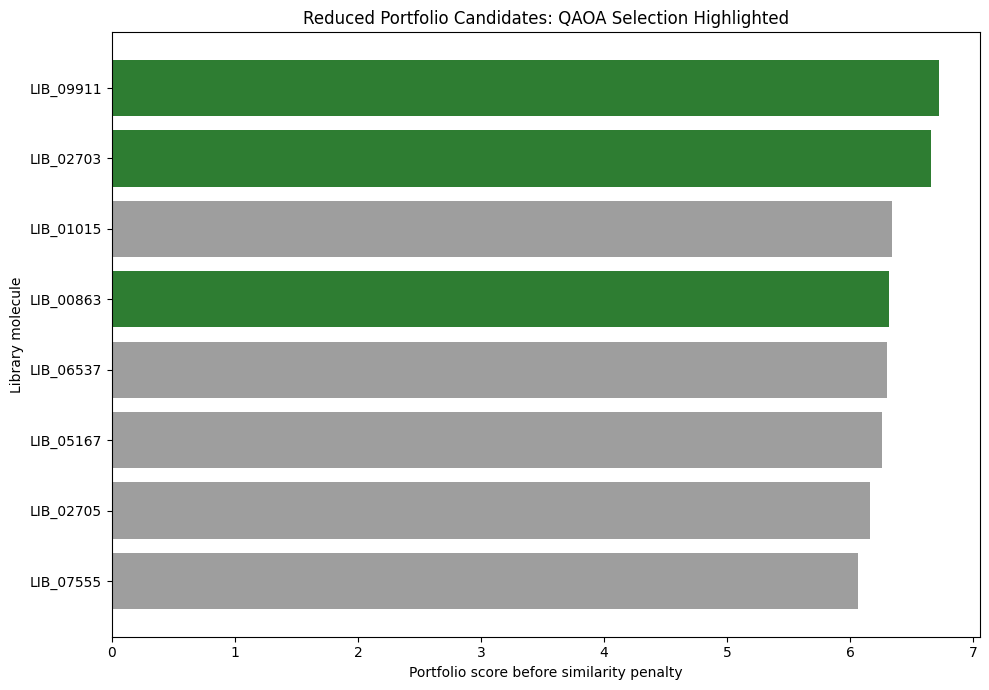

In [12]:
plot_frame = qaoa_candidates.copy()
plot_frame["selected_by_qaoa"] = plot_frame.index.isin(qaoa_indices)
plot_frame = plot_frame.sort_values("portfolio_score", ascending=True)
colors = np.where(plot_frame["selected_by_qaoa"], "#2e7d32", "#9e9e9e")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_frame["library_id"], plot_frame["portfolio_score"], color=colors)
ax.set_title("Reduced Portfolio Candidates: QAOA Selection Highlighted")
ax.set_xlabel("Portfolio score before similarity penalty")
ax.set_ylabel("Library molecule")
plt.tight_layout()
plt.show()

## 12. Takeaway

Classical optimization is not bad. For real pharma work today, it is usually the production baseline.

QAOA is interesting because the molecule portfolio problem naturally maps to binary optimization:

$$x_i = 1$$ means select molecule $i$, and $$x_i = 0$$ means reject it.

The full 10,000 choose 50 problem is too large for direct QAOA today. A realistic near-term architecture is:

1. Classical ML predicts molecule properties.
2. Classical filters reduce 10,000 molecules to a small high-quality shortlist.
3. QAOA optimizes the reduced constrained portfolio.
4. Classical optimization remains the baseline for quality, speed, and feasibility.

This notebook demonstrates that architecture without overstating current quantum capability.